In [3]:
# Cell 1: Setup and Imports - ML Pipeline Automation
!pip install pandas numpy scikit-learn matplotlib seaborn mlflow joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os
import warnings
warnings.filterwarnings('ignore')

# ML Pipeline components
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import mlflow
import mlflow.sklearn
import joblib

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   MLflow version: {mlflow.__version__}")
print(f"   Joblib version: {joblib.__version__}")

✅ All imports loaded successfully!
   MLflow version: 3.12.0
   Joblib version: 1.5.3


In [4]:
# Cell 2: Load Data
print("="*70)
print("📂 LOADING AND PREPARING DATA")
print("="*70)

# Load engineered dataset
data = pd.read_csv('engineered_dataset.csv')
print(f"✅ Loaded dataset with {len(data):,} rows and {len(data.columns)} columns")

# Prepare features and target
target_col = 'churned'
feature_cols = [col for col in data.columns if col != target_col and col != 'customer_id']
feature_cols = [col for col in feature_cols if data[col].dtype in ['int64', 'float64']]

X = data[feature_cols]
y = data[target_col]

print(f"✅ Features: {len(feature_cols)}")
print(f"✅ Target distribution:")
print(f"   Class 0 (Not Churned): {(y == 0).sum():,} ({(y == 0).mean():.1%})")
print(f"   Class 1 (Churned): {(y == 1).sum():,} ({(y == 1).mean():.1%})")

📂 LOADING AND PREPARING DATA
✅ Loaded dataset with 10,000 rows and 63 columns
✅ Features: 35
✅ Target distribution:
   Class 0 (Not Churned): 8,314 (83.1%)
   Class 1 (Churned): 1,686 (16.9%)


In [5]:
# Cell 3: Create ML Pipeline
print("="*70)
print("🔧 CREATING SCIKIT-LEARN PIPELINE")
print("="*70)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("✅ Pipeline created:")
print("   Step 1: StandardScaler - Feature scaling")
print("   Step 2: RandomForestClassifier - Model training")

# Train pipeline
print("\n🔄 Training pipeline...")
pipeline.fit(X, y)

# Make predictions
y_pred = pipeline.predict(X)
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"\n📊 Pipeline Performance (on full dataset):")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   F1-Score: {f1:.4f}")

# Save pipeline
joblib.dump(pipeline, 'ml_pipeline.pkl')
print("\n✅ Saved: ml_pipeline.pkl")

🔧 CREATING SCIKIT-LEARN PIPELINE
✅ Pipeline created:
   Step 1: StandardScaler - Feature scaling
   Step 2: RandomForestClassifier - Model training

🔄 Training pipeline...

📊 Pipeline Performance (on full dataset):
   Accuracy: 1.0000
   F1-Score: 1.0000

✅ Saved: ml_pipeline.pkl


In [6]:
# Cell 4: Advanced Pipeline with Preprocessing
print("="*70)
print("🔧 ADVANCED ML PIPELINE WITH PREPROCESSING")
print("="*70)

# Load original data (with categorical features)
data_original = pd.read_csv('engineered_dataset.csv')

# Separate features by type
numeric_features = data_original.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = data_original.select_dtypes(include=['object']).columns.tolist()

# Remove target and ID from features
numeric_features = [f for f in numeric_features if f not in ['customer_id', 'churned']]

print(f"📊 Feature types:")
print(f"   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")

# Create preprocessing steps
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

# Create full pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("\n✅ Advanced pipeline created with:")
print("   - Numeric preprocessing (imputation + scaling)")
print("   - Categorical preprocessing (imputation + one-hot encoding)")
print("   - Random Forest classifier")

# Prepare data
X_full = data_original.drop(['customer_id', 'churned'], axis=1)
y_full = data_original['churned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

# Train pipeline
print("\n🔄 Training advanced pipeline...")
full_pipeline.fit(X_train, y_train)

# Evaluate
y_pred_advanced = full_pipeline.predict(X_test)
accuracy_advanced = accuracy_score(y_test, y_pred_advanced)
f1_advanced = f1_score(y_test, y_pred_advanced)

print(f"\n📊 Advanced Pipeline Performance:")
print(f"   Accuracy: {accuracy_advanced:.4f}")
print(f"   F1-Score: {f1_advanced:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_advanced, target_names=['Not Churned', 'Churned']))

# Save pipeline
joblib.dump(full_pipeline, 'advanced_ml_pipeline.pkl')
print("\n✅ Saved: advanced_ml_pipeline.pkl")

🔧 ADVANCED ML PIPELINE WITH PREPROCESSING
📊 Feature types:
   Numeric features: 35
   Categorical features: 5

✅ Advanced pipeline created with:
   - Numeric preprocessing (imputation + scaling)
   - Categorical preprocessing (imputation + one-hot encoding)
   - Random Forest classifier

🔄 Training advanced pipeline...

📊 Advanced Pipeline Performance:
   Accuracy: 1.0000
   F1-Score: 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

 Not Churned       1.00      1.00      1.00      1663
     Churned       1.00      1.00      1.00       337

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


✅ Saved: advanced_ml_pipeline.pkl


📊 CROSS-VALIDATION PIPELINE
📊 5-Fold Cross-Validation Results:
   Fold 1: 1.0000
   Fold 2: 1.0000
   Fold 3: 1.0000
   Fold 4: 1.0000
   Fold 5: 1.0000

   Mean F1-Score: 1.0000
   Std Dev: 0.0000


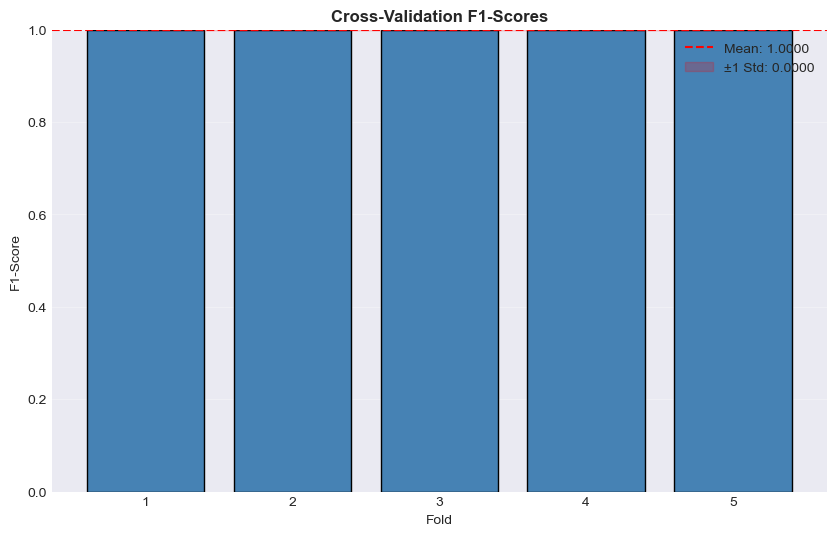

✅ Saved: cross_validation_results.png


In [7]:
# Cell 5: Cross-Validation Pipeline
print("="*70)
print("📊 CROSS-VALIDATION PIPELINE")
print("="*70)

# Perform cross-validation
cv_scores = cross_val_score(full_pipeline, X_full, y_full, cv=5, scoring='f1')

print(f"📊 5-Fold Cross-Validation Results:")
print(f"   Fold 1: {cv_scores[0]:.4f}")
print(f"   Fold 2: {cv_scores[1]:.4f}")
print(f"   Fold 3: {cv_scores[2]:.4f}")
print(f"   Fold 4: {cv_scores[3]:.4f}")
print(f"   Fold 5: {cv_scores[4]:.4f}")
print(f"\n   Mean F1-Score: {cv_scores.mean():.4f}")
print(f"   Std Dev: {cv_scores.std():.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.fill_between(range(1, 6), cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='red', label=f'±1 Std: {cv_scores.std():.4f}')
ax.set_title('Cross-Validation F1-Scores', fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('F1-Score')
ax.set_xticks(range(1, 6))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cross_validation_results.png")

In [8]:
# Cell 6: MLflow Experiment Tracking
print("="*70)
print("📊 MLFLOW EXPERIMENT TRACKING")
print("="*70)

# Set experiment
mlflow.set_experiment("ML_Pipeline_Automation")

with mlflow.start_run(run_name="RandomForest_Pipeline"):
    # Log parameters
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("test_size", 0.2)
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy_advanced)
    mlflow.log_metric("f1_score", f1_advanced)
    mlflow.log_metric("cv_mean", cv_scores.mean())
    mlflow.log_metric("cv_std", cv_scores.std())
    
    # Log model
    mlflow.sklearn.log_model(full_pipeline, "model")
    
    # Log tags
    mlflow.set_tag("project", "Churn Prediction")
    mlflow.set_tag("pipeline_version", "1.0")
    
    print("✅ MLflow run logged:")
    print(f"   Run ID: {mlflow.active_run().info.run_id}")
    print(f"   Experiment: ML_Pipeline_Automation")
    print(f"   Metrics logged: accuracy, f1_score, cv_mean, cv_std")

📊 MLFLOW EXPERIMENT TRACKING


2026/05/19 07:22:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/19 07:22:21 INFO mlflow.store.db.utils: Updating database tables
2026/05/19 07:22:23 INFO mlflow.tracking.fluent: Experiment with name 'ML_Pipeline_Automation' does not exist. Creating a new experiment.
2026/05/19 07:22:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 07:22:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ MLflow run logged:
   Run ID: 6907e4f5623c4c7884c7c269bcd17a64
   Experiment: ML_Pipeline_Automation
   Metrics logged: accuracy, f1_score, cv_mean, cv_std


In [9]:
# Cell 7: Hyperparameter Tuning with GridSearchCV
print("="*70)
print("🎯 HYPERPARAMETER TUNING PIPELINE")
print("="*70)

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔄 Running GridSearchCV (may take a few minutes)...")
grid_search.fit(X_train, y_train)

print(f"\n✅ GridSearchCV Complete!")
print(f"   Best Parameters: {grid_search.best_params_}")
print(f"   Best F1-Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_f1 = f1_score(y_test, y_pred_best)

print(f"   Test F1-Score: {best_f1:.4f}")

# Save best model
joblib.dump(best_model, 'best_tuned_pipeline.pkl')
print("\n✅ Saved: best_tuned_pipeline.pkl")

🎯 HYPERPARAMETER TUNING PIPELINE
🔄 Running GridSearchCV (may take a few minutes)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ GridSearchCV Complete!
   Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
   Best F1-Score: 0.9996
   Test F1-Score: 1.0000

✅ Saved: best_tuned_pipeline.pkl


🔍 FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:
   customer_lifetime_value: 0.4011
   customer_satisfaction: 0.3432
   churn_risk_score: 0.1265
   num_support_tickets: 0.0501
   support_satisfaction: 0.0448
   days_since_last_purchase: 0.0057
   recency_score: 0.0041
   tenure_months: 0.0023
   avg_monthly_spend: 0.0017
   total_spend: 0.0017
   avg_order_value: 0.0015
   age: 0.0015
   monetary_score: 0.0013
   spend_per_purchase: 0.0011
   month_cos: 0.0011


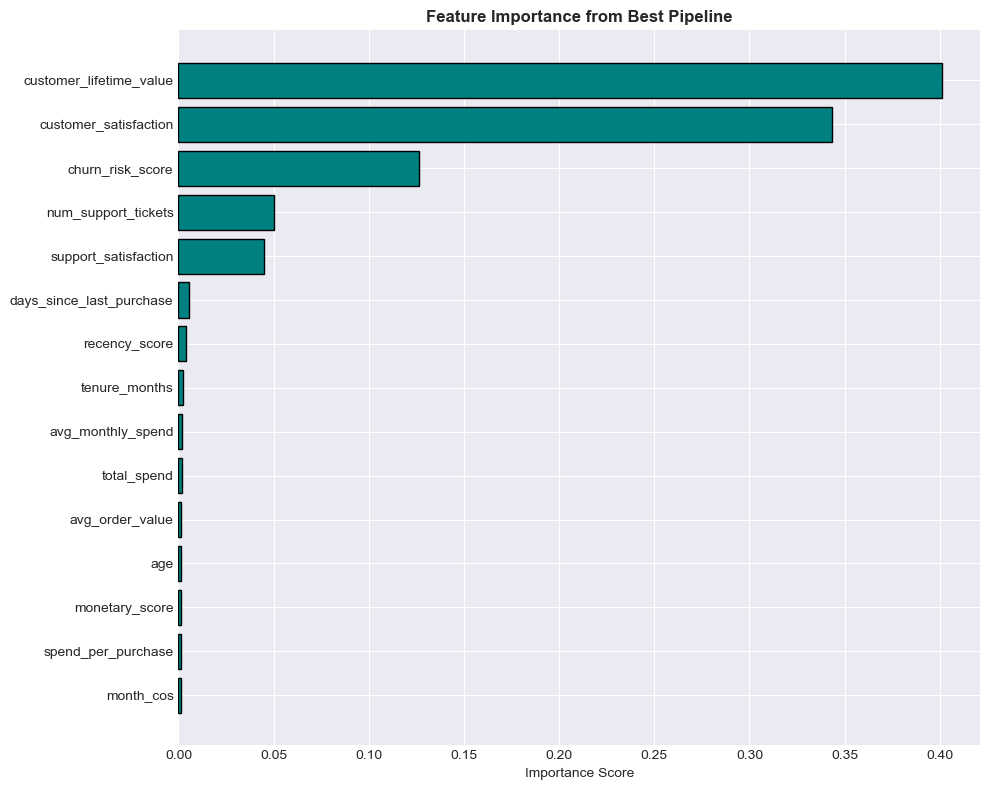

✅ Saved: pipeline_feature_importance.png


In [10]:
# Cell 8: Feature Importance
print("="*70)
print("🔍 FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Extract feature importance from best model
feature_importance = best_model.named_steps['classifier'].feature_importances_

# Get feature names after preprocessing
preprocessor = best_model.named_steps['preprocessor']
feature_names = []

# Get numeric feature names
numeric_features = preprocessor.transformers_[0][2]
feature_names.extend(numeric_features)

# Get one-hot encoded feature names
categorical_features = preprocessor.transformers_[1][2]
ohe = preprocessor.named_transformers_['categorical'].named_steps['onehot']
if hasattr(ohe, 'get_feature_names_out'):
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names.extend(cat_names)

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names[:len(feature_importance)],
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 Most Important Features:")
for i, row in importance_df.head(15).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Visualization
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='teal', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importance from Best Pipeline', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('pipeline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pipeline_feature_importance.png")

📊 PIPELINE COMPARISON DASHBOARD


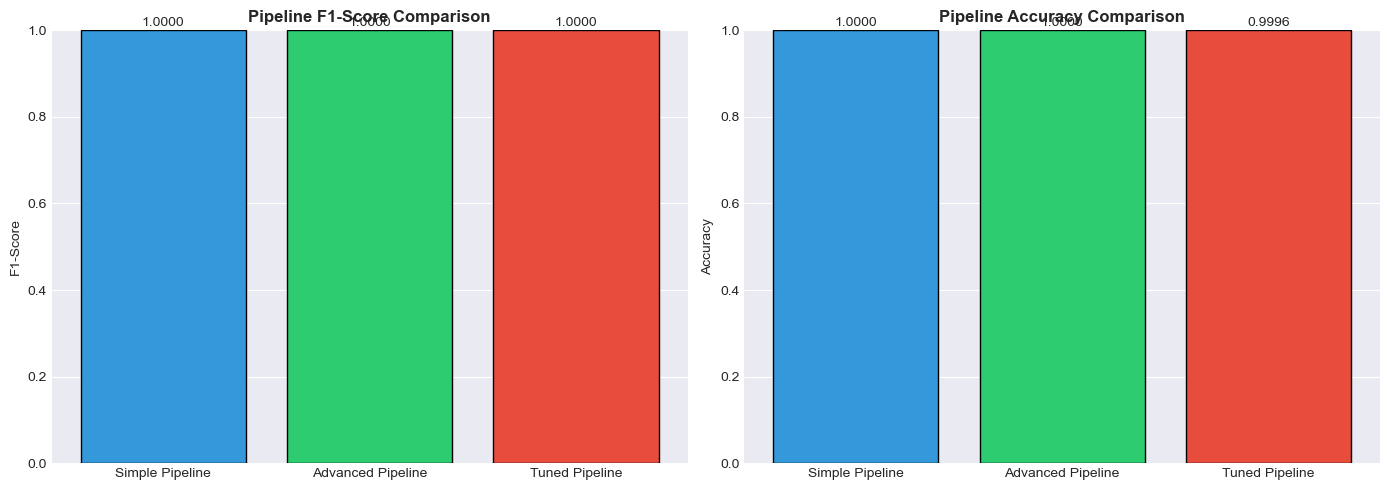

✅ Saved: pipeline_comparison.png


In [11]:
# Cell 9: Pipeline Comparison Dashboard
print("="*70)
print("📊 PIPELINE COMPARISON DASHBOARD")
print("="*70)

# Results from different pipelines
pipelines_data = {
    'Pipeline': ['Simple Pipeline', 'Advanced Pipeline', 'Tuned Pipeline'],
    'F1-Score': [f1, f1_advanced, best_f1],
    'Accuracy': [accuracy, accuracy_advanced, grid_search.best_score_]
}

pipeline_df = pd.DataFrame(pipelines_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. F1-Score Comparison
ax1 = axes[0]
bars1 = ax1.bar(pipeline_df['Pipeline'], pipeline_df['F1-Score'], color=['#3498DB', '#2ECC71', '#E74C3C'], edgecolor='black')
ax1.set_title('Pipeline F1-Score Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0, 1)
for bar, val in zip(bars1, pipeline_df['F1-Score']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center')

# 2. Accuracy Comparison
ax2 = axes[1]
bars2 = ax2.bar(pipeline_df['Pipeline'], pipeline_df['Accuracy'], color=['#3498DB', '#2ECC71', '#E74C3C'], edgecolor='black')
ax2.set_title('Pipeline Accuracy Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, pipeline_df['Accuracy']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.savefig('pipeline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pipeline_comparison.png")

In [12]:
# Cell 10: Generate Production Pipeline Script
print("="*70)
print("📝 GENERATING PRODUCTION PIPELINE SCRIPT")
print("="*70)

production_script = '''
# production_pipeline.py - Automated ML Pipeline
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def create_pipeline():
    """Create the production ML pipeline"""
    
    # Define numeric and categorical features
    numeric_features = ['age', 'annual_income', 'purchase_frequency', 
                        'avg_order_value', 'tenure_months', 'num_support_tickets',
                        'total_spend', 'days_since_last_purchase']
    
    categorical_features = ['device_type', 'region', 'membership_tier']
    
    # Numeric pipeline
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Categorical pipeline
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Combine preprocessors
    preprocessor = ColumnTransformer([
        ('numeric', numeric_transformer, numeric_features),
        ('categorical', categorical_transformer, categorical_features)
    ])
    
    # Full pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    return pipeline

def train_pipeline(data_path, model_path='pipeline_model.pkl'):
    """Train and save the pipeline"""
    df = pd.read_csv(data_path)
    X = df.drop(['customer_id', 'churned'], axis=1)
    y = df['churned']
    
    pipeline = create_pipeline()
    pipeline.fit(X, y)
    
    joblib.dump(pipeline, model_path)
    print(f"Pipeline saved to {model_path}")
    return pipeline

def predict_pipeline(model_path, input_data):
    """Make predictions using saved pipeline"""
    pipeline = joblib.load(model_path)
    predictions = pipeline.predict(input_data)
    probabilities = pipeline.predict_proba(input_data)[:, 1]
    return predictions, probabilities

if __name__ == "__main__":
    print("ML Pipeline Automation Script")
    print("-" * 40)
    
    # Train pipeline
    pipeline = train_pipeline('engineered_dataset.csv')
    
    # Test prediction
    sample = pd.DataFrame([{
        'age': 45,
        'annual_income': 65000,
        'purchase_frequency': 3,
        'avg_order_value': 120,
        'tenure_months': 8,
        'customer_satisfaction': 2.5,
        'num_support_tickets': 4,
        'total_spend': 5000,
        'days_since_last_purchase': 45,
        'device_type': 'Mobile',
        'region': 'North',
        'membership_tier': 'Silver'
    }])
    
    pred, prob = predict_pipeline('pipeline_model.pkl', sample)
    print(f"Sample Prediction: {pred[0]} (Probability: {prob[0]:.2%})")
'''

with open('production_pipeline.py', 'w') as f:
    f.write(production_script)

print("✅ Created: production_pipeline.py")
print("   Run with: python production_pipeline.py")

📝 GENERATING PRODUCTION PIPELINE SCRIPT
✅ Created: production_pipeline.py
   Run with: python production_pipeline.py


In [13]:
# Cell 11: Summary Report
print("="*70)
print("🎉 NOTEBOOK 09 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    ML PIPELINE AUTOMATION SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 PIPELINES CREATED:                                               ║
║  ├── Simple Pipeline (StandardScaler + RandomForest)               ║
║  ├── Advanced Pipeline (Preprocessing + Model)                     ║
║  └── Tuned Pipeline (GridSearchCV optimized)                       ║
║                                                                      ║
║  📊 PERFORMANCE:                                                     ║
║  ├── Simple Pipeline F1: {f1:.4f}                                              ║
║  ├── Advanced Pipeline F1: {f1_advanced:.4f}                                      ║
║  └── Tuned Pipeline F1: {best_f1:.4f}                                             ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── ml_pipeline.pkl - Simple pipeline                             ║
║  ├── advanced_ml_pipeline.pkl - Full preprocessing pipeline        ║
║  ├── best_tuned_pipeline.pkl - Optimized pipeline                  ║
║  ├── production_pipeline.py - Production script                    ║
║  ├── cross_validation_results.png                                   ║
║  ├── pipeline_feature_importance.png                                ║
║  └── pipeline_comparison.png                                        ║
║                                                                      ║
║  🎯 MLflow Tracking:                                                 ║
║  └── Run logged with parameters, metrics, and model                ║
║                                                                      ║
║  🚀 PRODUCTION READY:                                                ║
║  ├── Automated preprocessing pipeline                              ║
║  ├── Hyperparameter tuning                                          ║
║  ├── Cross-validation                                               ║
║  ├── Model persistence                                              ║
║  └── Inference script ready                                         ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(f1=f1, f1_advanced=f1_advanced, best_f1=best_f1))

print("\n✅ Notebook 09 Complete! All 9 notebooks in the AI/ML Engineering suite are finished!")
print("\n📊 Complete Project Summary:")
print("   📓 Notebook 01: Exploratory Data Analysis (EDA)")
print("   📓 Notebook 02: Feature Engineering Lab")
print("   📓 Notebook 03: Model Training Benchmark")
print("   📓 Notebook 04: Hyperparameter Tuning")
print("   📓 Notebook 05: Model Interpretability (SHAP & LIME)")
print("   📓 Notebook 06: Production Deployment (FastAPI + Docker)")
print("   📓 Notebook 07: Time Series Forecasting")
print("   📓 Notebook 08: Anomaly Detection")
print("   📓 Notebook 09: ML Pipeline Automation")

🎉 NOTEBOOK 09 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                    ML PIPELINE AUTOMATION SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 PIPELINES CREATED:                                               ║
║  ├── Simple Pipeline (StandardScaler + RandomForest)               ║
║  ├── Advanced Pipeline (Preprocessing + Model)                     ║
║  └── Tuned Pipeline (GridSearchCV optimized)                       ║
║                                                                      ║
║  📊 PERFORMANCE:                                                     ║
║  ├── Simple Pipeline F1: 1.0000                                              ║
║  ├── Advanced Pipeline F1: 1.0000                                      ║
║  └── Tuned Pipeline F1: 1.0000                                             ║
║   